In [14]:
import pandas as pd

In [15]:
data = pd.read_csv("../Dataset/Augmented_Categorical_Data.csv")

In [16]:
data.rename(columns={
    "What best describes the place you grew up in? ": "Place_Grew_Up",
    "When considering a purchase, how important are the following factors to you?  [Price/Cost]": "Price_Importance",
    "When considering a purchase, how important are the following factors to you?  [Brand reputation]": "Brand_Importance",
    "When considering a purchase, how important are the following factors to you?  [Peer recommendation]": "Peer_Importance",
    "When considering a purchase, how important are the following factors to you?  [Long-term utility/value]": "Utility_Importance"
}, inplace=True)


data.rename(columns={
    "How do you track your monthly expenditures? ": "Track_Expenditures",
    "What is the expected graph for your expenditure for the months ": "Expenditure_Graph"
}, inplace=True)


data.rename(columns={
    "In which of the following scenarios would you justify an unexpected expense of ₹1,500 or more?": "Justify_Unexpected_Expense"
}, inplace=True)

data.rename(columns={
    "How often do you make purchases that you hadn’t planned for? ": "Unplanned_Purchases",
    "On average, how much do you spend per month (excluding tuition fees)? ": "Monthly_Spend",
    "On a scale of 1 to 5, how much do social events or peer pressure influence your spending? ": "Peer_Influence",
    "How confident do you feel in your ability to manage your personal finances? ": "Finance_Confidence"
}, inplace=True)

data.rename(columns={
    "In which categories do you spend the majority of your budget?  [Food & Dining]": "Budget_FoodDining",
    "In which categories do you spend the majority of your budget?  [Travel]": "Budget_Travel",
    "In which categories do you spend the majority of your budget?  [Fashion]": "Budget_Fashion",
    "In which categories do you spend the majority of your budget?  [Subscriptions (Netflix, Spotify, etc.)]": "Budget_Subscriptions",
    "In which categories do you spend the majority of your budget?  [Fun & Entertainment]": "Budget_Entertainment"
}, inplace=True)


In [17]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 507 entries, 0 to 506
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Place_Grew_Up               507 non-null    str  
 1   Price_Importance            507 non-null    str  
 2   Brand_Importance            507 non-null    str  
 3   Peer_Importance             507 non-null    str  
 4   Utility_Importance          507 non-null    str  
 5   Track_Expenditures          507 non-null    str  
 6   Expenditure_Graph           507 non-null    str  
 7   Justify_Unexpected_Expense  355 non-null    str  
 8   Unplanned_Purchases         507 non-null    int64
 9   Peer_Influence              507 non-null    int64
 10  Finance_Confidence          507 non-null    int64
 11  Monthly_Spend               507 non-null    int64
 12  Group                       507 non-null    int64
 13  Budget_FoodDining           507 non-null    str  
 14  Budget_Travel        

In [18]:
from sklearn.impute import SimpleImputer

budget_cols = ["Budget_FoodDining", "Budget_Travel","Budget_Fashion", "Budget_Subscriptions","Budget_Entertainment"]
data[budget_cols] = data[budget_cols].astype(object)
data[budget_cols] = data[budget_cols].replace("Answer", "Yes")

imputer = SimpleImputer(strategy="constant", fill_value="No")
data[budget_cols] = imputer.fit_transform(data[budget_cols])

data[budget_cols] = data[budget_cols].astype(object)

In [19]:
data["Expenditure_Graph"] = data["Expenditure_Graph"].astype(str)
#data.drop(columns=["Justify_Unexpected_Expense"], inplace=True)

In [20]:
data.head()

,Place_Grew_Up,Price_Importance,Brand_Importance,Peer_Importance,Utility_Importance,Track_Expenditures,Expenditure_Graph,Justify_Unexpected_Expense,Unplanned_Purchases,Peer_Influence,Finance_Confidence,Monthly_Spend,Group,Budget_FoodDining,Budget_Travel,Budget_Fashion,Budget_Subscriptions,Budget_Entertainment
0,🏘️ Small town,Very important,Slightly important,Not important,Very important,"I review my history within payment apps (e.g.,...",Irregular and Random Spending,NaN,2,3,4,3,1,No,Yes,No,No,No
1,🏢 Medium-sized city,Very important,Slightly important,Slightly important,Very important,"I review my history within payment apps (e.g.,...",Steady Weekdays with High Weekends,A planned trip with friends.,3,3,4,4,2,Yes,No,No,No,No
2,🏙️ Big metro city,Very important,Very important,Very important,Very important,"I review my history within payment apps (e.g.,...",Steady Weekdays with High Weekends,"A 50% discount on a brand I highly value., Soc...",5,4,4,10,3,Yes,Yes,Yes,Yes,Yes
3,🏢 Medium-sized city,Very important,Very important,Slightly important,Very important,"I review my history within payment apps (e.g.,...",Spend a lot once and then low spending for rest,"Social celebrations or parties., A planned tri...",2,3,3,4,2,No,Yes,No,No,No
4,🏙️ Big metro city,Very important,Very important,Very important,Very important,"I review my history within payment apps (e.g.,...",Steady Weekdays with High Weekends,"A 50% discount on a brand I highly value., Soc...",5,4,4,10,3,Yes,Yes,Yes,Yes,Yes


In [21]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import normalized_mutual_info_score, accuracy_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. Preprocessing - Force Encoding and Scaling
X = data.drop(columns=['Monthly_Spend', 'Group', 'Risk_Group'], errors='ignore')
y = data['Group'].values

# Encode Categories
for col in X.columns:
    if not pd.api.types.is_numeric_dtype(X[col]):
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str).fillna('Missing'))

# Scaling is CRITICAL for SVM and KNN
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Define the 6 Models
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, class_weight='balanced'),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    "SVM (RBF Kernel)": SVC(kernel='rbf', probability=True, random_state=42, class_weight='balanced'),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(solver='lbfgs', max_iter=1000, class_weight='balanced')
}

# 3. K-Fold Competition Loop
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
comparison_results = []

print(f"🏆 Supervised Model Battle: 6-Way Comparison for 3 Risk Tiers")
print("-" * 75)
print(f"{'Model':<20} | {'Mean NMI':<15} | {'Mean Accuracy':<15}")
print("-" * 75)

for name, model in models.items():
    fold_nmis = []
    fold_accs = []
    
    # We use X_scaled for distance-based models (SVM/KNN) and X for tree models
    # but scaled data works for both, so we use X_scaled for consistency.
    for train_idx, val_idx in skf.split(X_scaled, y):
        X_train, X_val = X_scaled[train_idx], X_scaled[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        
        fold_nmis.append(normalized_mutual_info_score(y_val, y_pred))
        fold_accs.append(accuracy_score(y_val, y_pred))
    
    mean_nmi = np.mean(fold_nmis)
    mean_acc = np.mean(fold_accs)
    comparison_results.append({"Model": name, "NMI": mean_nmi, "Accuracy": mean_acc})
    
    print(f"{name:<20} | {mean_nmi:<15.4f} | {mean_acc:<15.4f}")

# 4. Final Verdict
best_model_info = max(comparison_results, key=lambda x: x['NMI'])
print("-" * 75)
print(f"🌟 BEST PERFORMER: {best_model_info['Model']} (NMI: {best_model_info['NMI']:.4f})")

🏆 Supervised Model Battle: 6-Way Comparison for 3 Risk Tiers
---------------------------------------------------------------------------
Model                | Mean NMI        | Mean Accuracy  
---------------------------------------------------------------------------
Random Forest        | 0.6954          | 0.8975         
Gradient Boosting    | 0.6428          | 0.8777         
Extra Trees          | 0.7650          | 0.9270         
SVM (RBF Kernel)     | 0.6935          | 0.8915         
KNN (k=5)            | 0.5102          | 0.8008         
Logistic Regression  | 0.2239          | 0.6586         
---------------------------------------------------------------------------
🌟 BEST PERFORMER: Extra Trees (NMI: 0.7650)


In [22]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import normalized_mutual_info_score, accuracy_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder

# 1. Final Preprocessing Check
# Assuming 'data' is loaded and 'Risk_Group' is already mapped (0, 1, 2)
X_full = data.drop(columns=['Monthly_Spend', 'Group', 'Risk_Group',"Budget_Subscriptions","Peer_Influence"], errors='ignore')
y = data['Group'].values

# Encode all features once for consistency
for col in X_full.columns:
    if not pd.api.types.is_numeric_dtype(X_full[col]):
        le = LabelEncoder()
        X_full[col] = le.fit_transform(X_full[col].astype(str).fillna('Missing'))

# 2. Setup Cross-Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def get_rf_scores(features_df, labels):
    nmis = []
    accs = []
    for train_idx, val_idx in skf.split(features_df, labels):
        X_t, X_v = features_df.iloc[train_idx], features_df.iloc[val_idx]
        y_t, y_v = labels[train_idx], labels[val_idx]
        
        model = RandomForestClassifier(n_estimators=150, max_depth=8, random_state=42, class_weight='balanced')
        model.fit(X_t, y_t)
        y_p = model.predict(X_v)
        
        nmis.append(normalized_mutual_info_score(y_v, y_p))
        accs.append(accuracy_score(y_v, y_p))
    return np.mean(nmis), np.mean(accs)

# 3. Baseline Run
base_nmi, base_acc = get_rf_scores(X_full, y)
print(f"📊 BASELINE (All Features): NMI={base_nmi:.4f}, Accuracy={base_acc:.4f}")
print("-" * 65)
print(f"{'Dropped Variable':<25} | {'NMI':<10} | {'Accuracy':<10} | {'Status'}")
print("-" * 65)

optimization_results = []

# 4. Optimization Loop
for col in X_full.columns:
    X_temp = X_full.drop(columns=[col])
    temp_nmi, temp_acc = get_rf_scores(X_temp, y)
    
    status = "⭐ IMPROVED" if temp_nmi > base_nmi else ""
    print(f"{col:<25} | {temp_nmi:<10.4f} | {temp_acc:<10.4f} | {status}")
    
    optimization_results.append({
        "Dropped": col,
        "NMI": temp_nmi,
        "Accuracy": temp_acc
    })

# 5. Summary
opt_df = pd.DataFrame(optimization_results).sort_values(by='NMI', ascending=False)
best_drop = opt_df.iloc[0]
print("-" * 65)
print(f"🏆 Best Result: Dropping '{best_drop['Dropped']}'")
print(f"📈 New NMI: {best_drop['NMI']:.4f} (Base: {base_nmi:.4f})")

📊 BASELINE (All Features): NMI=0.7584, Accuracy=0.9191
-----------------------------------------------------------------
Dropped Variable          | NMI        | Accuracy   | Status
-----------------------------------------------------------------
Place_Grew_Up             | 0.6828     | 0.8914     | 
Price_Importance          | 0.6861     | 0.8955     | 
Brand_Importance          | 0.7228     | 0.9092     | 
Peer_Importance           | 0.6927     | 0.8935     | 
Utility_Importance        | 0.7054     | 0.8974     | 
Track_Expenditures        | 0.7140     | 0.8994     | 
Expenditure_Graph         | 0.6782     | 0.8856     | 
Justify_Unexpected_Expense | 0.6922     | 0.8974     | 
Unplanned_Purchases       | 0.6980     | 0.8955     | 
Finance_Confidence        | 0.6823     | 0.8935     | 
Budget_FoodDining         | 0.7035     | 0.9013     | 
Budget_Travel             | 0.6411     | 0.8738     | 
Budget_Fashion            | 0.6969     | 0.8994     | 
Budget_Entertainment      | 0.6919  

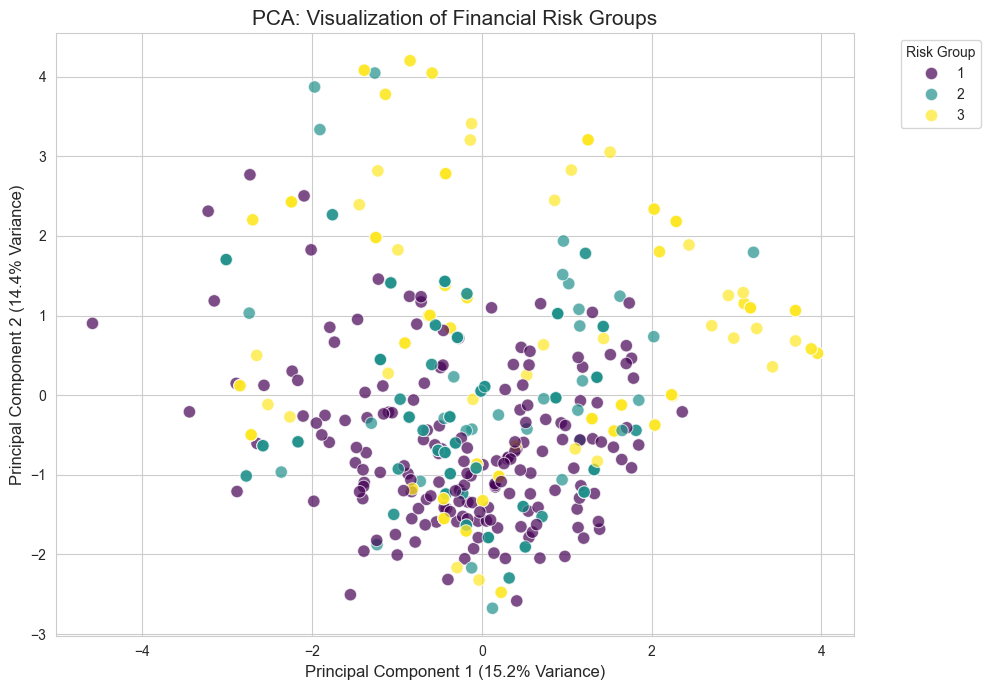

Total Explained Variance (PC1 + PC2): 29.56%


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Standardize the data 
# (PCA is sensitive to variances, so scaling is mandatory)
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_full)
# 2. Apply PCA
# We choose 2 components for a 2D visualization
pca = PCA(n_components=2)
pca_results = pca.fit_transform(X_scaled)

# 3. Create a DataFrame for plotting
pca_df = pd.DataFrame(data=pca_results, columns=['PC1', 'PC2'])
pca_df['Group'] = y  # Your target groups (0, 1, 2)

# 4. Visualization
plt.figure(figsize=(10, 7))
sns.set_style("whitegrid")

# Plotting the clusters
scatter = sns.scatterplot(
    x='PC1', 
    y='PC2', 
    hue='Group', 
    palette='viridis', 
    data=pca_df, 
    alpha=0.7, 
    edgecolor='w',
    s=80
)

# Adding titles and labels
plt.title('PCA: Visualization of Financial Risk Groups', fontsize=15)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)', fontsize=12)
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)', fontsize=12)
plt.legend(title='Risk Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

# 5. Check Variance Explanation
print(f"Total Explained Variance (PC1 + PC2): {np.sum(pca.explained_variance_ratio_)*100:.2f}%")

In [24]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from scipy.spatial.distance import cdist

# --- PREPARATION ---
# Select the best features identified from your previous "Drop-One-Out" step
X = data.drop(columns=['Timestamp', 'Risk_Group', 'Monthly_Spend'], errors='ignore').copy()

# Encode categories
for col in X.columns:
    if not pd.api.types.is_numeric_dtype(X[col]):
        X[col] = pd.factorize(X[col])[0]
X = X.fillna(X.median())
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =========================================================
# METHOD 1: K-MEANS + DISTANCE (Friend's Logic)
# =========================================================
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
centroids = kmeans.cluster_centers_

# Logic to find the "Safe" cluster
# We use the average of your 1-3 Risk Group as the reference
safe_reference = X_scaled[data['Group'] == 1].mean(axis=0)
distances = cdist(X_scaled, [safe_reference], metric='euclidean').flatten()

score_scaler = MinMaxScaler(feature_range=(1, 100))
data['KMeans_Distance_Score'] = score_scaler.fit_transform(distances.reshape(-1, 1)).flatten().round(2)

# =========================================================
# METHOD 2: ISOLATION FOREST (Friend's Logic)
# =========================================================
iso_forest = IsolationForest(contamination=0.1, random_state=42)
iso_forest.fit(X_scaled)

# decision_function returns negative values for anomalies
anomaly_scores = iso_forest.decision_function(X_scaled)
# Invert: More isolated = Higher score
data['IForest_Anomaly_Score'] = score_scaler.fit_transform(-anomaly_scores.reshape(-1, 1)).flatten().round(2)

# =========================================================
# METHOD 3: THE RF-WEIGHTED DISTANCE (Optimized Version)
# =========================================================
rf = RandomForestClassifier(n_estimators=150, random_state=42)
rf.fit(X_scaled, data['Group'])
importances = rf.feature_importances_

# Weight the data by importance before calculating distance
weighted_X = X_scaled * importances
weighted_safe = safe_reference * importances
rf_distances = cdist(weighted_X, [weighted_safe], metric='euclidean').flatten()

data['RF_Weighted_Score'] = score_scaler.fit_transform(rf_distances.reshape(-1, 1)).flatten().round(2)

# --- RESULTS ---
print("✅ All three scoring methods applied successfully!")
print(data[['Group','KMeans_Distance_Score', 'IForest_Anomaly_Score', 'RF_Weighted_Score']].head(50))

✅ All three scoring methods applied successfully!
    Group  KMeans_Distance_Score  IForest_Anomaly_Score  RF_Weighted_Score
0       1                  40.09                  44.90               2.66
1       2                  10.48                   1.00              48.22
2       3                  67.92                  18.73              99.61
3       2                  36.34                  35.52              48.18
4       3                  67.92                  18.73              99.61
5       1                  15.03                  21.32               2.54
6       2                  11.03                   4.93              48.21
7       1                  26.16                  27.64               2.50
8       3                  68.02                  41.84              99.29
9       3                  52.00                  41.89              98.98
10      1                  38.58                  59.14               4.89
11      1                  68.48                  

In [25]:
score = data["RF_Weighted_Score"]
dd = pd.read_csv("../Dataset/Augmented_Categorical_Data.csv")
dd["Risk_score"] = score
dd.to_csv("../Dataset/Scored_Categorical_Data.csv")
dd = pd.read_csv("../Dataset/Augmented_Cleaned_Data.csv")
dd["Risk_score"] = score
dd.to_csv("../Dataset/Scored_Cleaned_data.csv")

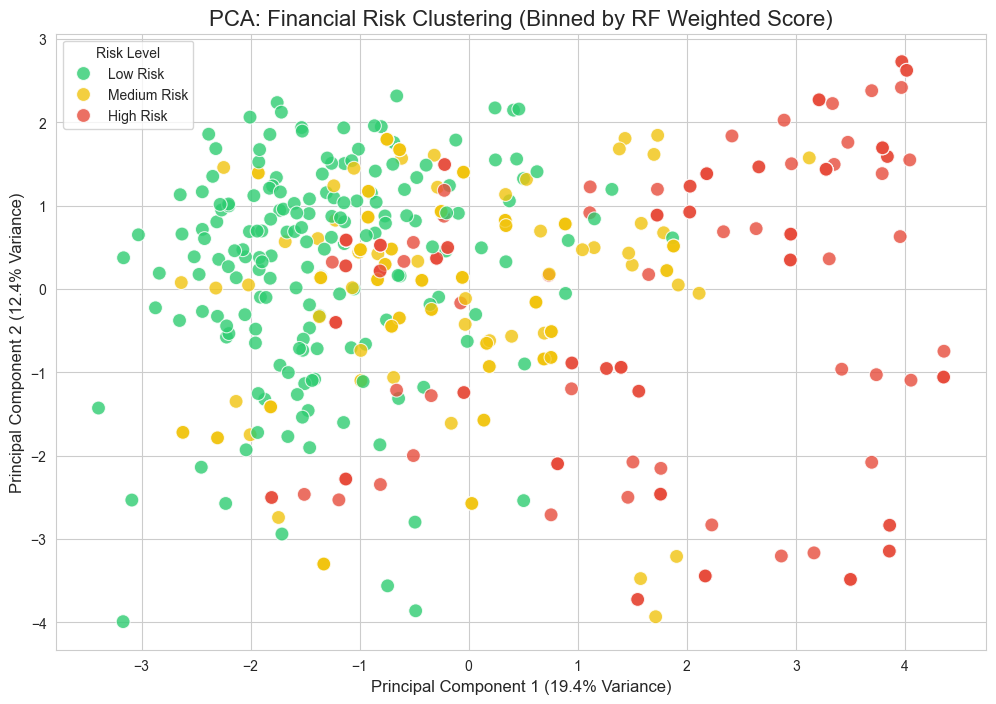

Total variance captured by 2 components: 31.75%


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. Define the New Risk Groups based on RF_Weighted_Score
def categorize_risk(score):
    if score <= 33:
        return 'Low Risk'
    elif score <= 66:
        return 'Medium Risk'
    else:
        return 'High Risk'

data['Risk_Level'] = data['RF_Weighted_Score'].apply(categorize_risk)

# 2. Prepare the Features (X)
# Dropping the requested columns for PCA
drop_cols = ['Group', 'KMeans_Distance_Score', 'IForest_Anomaly_Score', 'RF_Weighted_Score', 'Risk_Level']
X = data.drop(columns=drop_cols, errors='ignore').copy()

# 3. Encode Categorical Variables
# PCA requires numeric input, so we encode strings/objects
for col in X.columns:
    if X[col].dtype == 'object' or X[col].dtype == 'str':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))

# 4. Standardize the Data
# PCA is extremely sensitive to the scale of features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Apply PCA
pca = PCA(n_components=2)
pca_components = pca.fit_transform(X_scaled)

# Create a DataFrame for plotting
pca_df = pd.DataFrame(data=pca_components, columns=['PC1', 'PC2'])
pca_df['Risk_Level'] = data['Risk_Level'].values

# 6. Visualization
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Custom palette for risk levels
palette = {'Low Risk': '#2ecc71', 'Medium Risk': '#f1c40f', 'High Risk': '#e74c3c'}

sns.scatterplot(
    x='PC1', 
    y='PC2', 
    hue='Risk_Level', 
    hue_order=['Low Risk', 'Medium Risk', 'High Risk'],
    palette=palette,
    data=pca_df,
    s=100, 
    alpha=0.8,
    edgecolor='w'
)

# Adding labels and explained variance
exp_var = pca.explained_variance_ratio_ * 100
plt.title('PCA: Financial Risk Clustering (Binned by RF Weighted Score)', fontsize=16)
plt.xlabel(f'Principal Component 1 ({exp_var[0]:.1f}% Variance)', fontsize=12)
plt.ylabel(f'Principal Component 2 ({exp_var[1]:.1f}% Variance)', fontsize=12)
plt.legend(title='Risk Level', loc='best')

plt.show()

# Print explained variance summary
print(f"Total variance captured by 2 components: {sum(exp_var):.2f}%")